In [1]:
import geopandas as gpd
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import shapely.wkt
import shapely.geometry
import pandas as pd
import shapely.geometry.multipolygon as sh
import rioxarray

In [2]:
slp = rioxarray.open_rasterio('Data\\tha_slope\\tha_slp_int\\w001001.adf',masked=True)
xr_slp = slp.coarsen(x = 3, y= 3, boundary='pad').mean()
xr_slp = xr_slp.sel(band = 1)
xr_slp = xr_slp.drop_vars('band')
xr_slp = xr_slp.drop('spatial_ref', dim=None)
xr_slp = xr_slp.rename({'x':'lon'})
xr_slp = xr_slp.rename({'y':'lat'})
xr_slp = xr_slp.to_dataset(name='slp')
df_slp = xr_slp.to_dataframe()
df_slp.reset_index(inplace=True)
df_slp = gpd.GeoDataFrame(df_slp, geometry =gpd.points_from_xy(df_slp['lon'],df_slp['lat']))
df_slp.crs = {'init': 'epsg:4326'}
print(df_slp['slp'].max())
df_slp['slp']= df_slp['slp'].fillna(100)


C:\Users\595078\AppData\Local\Temp\ipykernel_2872\2036231463.py:5: DeprecationWarning: dropping variables using `drop` is deprecated; use drop_vars.
  xr_slp = xr_slp.drop('spatial_ref', dim=None)


59.22222137451172


d:\workstation\RESITING\.env\Lib\site-packages\pyproj\crs\crs.py:141: FutureWarning: '+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-changes-in-proj-6
  in_crs_string = _prepare_from_proj_string(in_crs_string)


In [3]:
xr_landuse_suitability_index = xr.open_dataset('Output\\xr_SI_Landcover.nc')
df_slope_suitability_index = xr_landuse_suitability_index.to_dataframe()
df_slope_suitability_index.reset_index(inplace=True)
df_slope_suitability_index = gpd.GeoDataFrame(df_slope_suitability_index, geometry =gpd.points_from_xy(df_slope_suitability_index['lon'],df_slope_suitability_index['lat']))
df_slope_suitability_index.crs = {'init': 'epsg:4326'}
df_slope_suitability_index['SI_BGEC'] = 0
df_slope_suitability_index['SI_Biomass'] = 0
df_slope_suitability_index['SI_Solar'] = 0
df_slope_suitability_index['SI_Wind'] = 0
df_slope_suitability_index['SI_BGWW'] = 0
df_slope_suitability_index['SI_MSW'] = 0
df_slope_suitability_index['SI_IEW'] = 0

d:\workstation\RESITING\.env\Lib\site-packages\pyproj\crs\crs.py:141: FutureWarning: '+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-changes-in-proj-6
  in_crs_string = _prepare_from_proj_string(in_crs_string)


In [4]:
df_slope_suitability_index = gpd.sjoin_nearest(df_slope_suitability_index,df_slp,how='left')

for i in df_slope_suitability_index.columns:
    if i not in (['lon_left','lat_left','geometry','slp','SI_BGEC','SI_Biomass','SI_Solar','SI_Wind','SI_BGWW','SI_MSW','SI_IEW']):
        df_slope_suitability_index = df_slope_suitability_index.drop(columns=i)

df_slope_suitability_index = df_slope_suitability_index.rename(columns= {'lon_left' : 'lon'})
df_slope_suitability_index = df_slope_suitability_index.rename(columns= {'lat_left' : 'lat'})
df_slope_suitability_index['slp']= df_slope_suitability_index['slp'].fillna(100)

print(df_slope_suitability_index)

d:\workstation\RESITING\.env\Lib\site-packages\geopandas\array.py:403: UserWarning: Geometry is in a geographic CRS. Results from 'sjoin_nearest' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  warnings.warn(


                lat         lon  SI_Solar  SI_Wind  SI_BGEC  SI_Biomass  \
0          5.615278   97.345833         0        0        0           0   
1          5.615278   97.348611         0        0        0           0   
2          5.615278   97.351389         0        0        0           0   
3          5.615278   97.354167         0        0        0           0   
4          5.615278   97.356944         0        0        0           0   
...             ...         ...       ...      ...      ...         ...   
15957805  20.462500  105.623611         0        0        0           0   
15957806  20.462500  105.626389         0        0        0           0   
15957807  20.462500  105.629167         0        0        0           0   
15957808  20.462500  105.631944         0        0        0           0   
15957809  20.462500  105.634722         0        0        0           0   

          SI_BGWW  SI_MSW  SI_IEW                   geometry    slp  
0               0       0    

In [5]:
## SI_BGEC ##
df_slope_suitability_index['SI_BGEC'].loc[df_slope_suitability_index['slp'] > 15] = 0
df_slope_suitability_index['SI_BGEC'].loc[(df_slope_suitability_index['slp'] > 5) & (df_slope_suitability_index['slp'] <= 15)] = 2
df_slope_suitability_index['SI_BGEC'].loc[df_slope_suitability_index['slp'] <= 5 ] = 3

## SI_Biomass ##
df_slope_suitability_index['SI_Biomass'].loc[df_slope_suitability_index['slp'] > 15] = 0
df_slope_suitability_index['SI_Biomass'].loc[(df_slope_suitability_index['slp'] > 5) & (df_slope_suitability_index['slp'] <= 15)] = 2
df_slope_suitability_index['SI_Biomass'].loc[df_slope_suitability_index['slp'] <= 5 ] = 3

## SI for Solar ##
df_slope_suitability_index['SI_Solar'].loc[df_slope_suitability_index['slp'] > 5] = 0
df_slope_suitability_index['SI_Solar'].loc[(df_slope_suitability_index['slp'] > 1) & (df_slope_suitability_index['slp'] <= 5)] =2
df_slope_suitability_index['SI_Solar'].loc[df_slope_suitability_index['slp'] <=1 ] = 3

## SI_Wind ##
df_slope_suitability_index['SI_Wind'].loc[df_slope_suitability_index['slp'] > 15] = 0
df_slope_suitability_index['SI_Wind'].loc[(df_slope_suitability_index['slp'] > 7) & (df_slope_suitability_index['slp'] <= 15)] =2
df_slope_suitability_index['SI_Wind'].loc[df_slope_suitability_index['slp'] <= 7 ] = 3

## SI_BGWW ##
df_slope_suitability_index['SI_BGWW'].loc[df_slope_suitability_index['slp'] > 15] = 0
df_slope_suitability_index['SI_BGWW'].loc[(df_slope_suitability_index['slp'] > 5) & (df_slope_suitability_index['slp'] <= 15)] = 2
df_slope_suitability_index['SI_BGWW'].loc[df_slope_suitability_index['slp'] <= 5 ] = 3

## SI_MSW ##
df_slope_suitability_index['SI_MSW'].loc[df_slope_suitability_index['slp'] > 15] = 0
df_slope_suitability_index['SI_MSW'].loc[(df_slope_suitability_index['slp'] > 5) & (df_slope_suitability_index['slp'] <= 15)] = 2
df_slope_suitability_index['SI_MSW'].loc[df_slope_suitability_index['slp'] <= 5 ] = 3

## SI_IEW ##
df_slope_suitability_index['SI_IEW'].loc[df_slope_suitability_index['slp'] > 15] = 0
df_slope_suitability_index['SI_IEW'].loc[(df_slope_suitability_index['slp'] > 5) & (df_slope_suitability_index['slp'] <= 15)] = 2
df_slope_suitability_index['SI_IEW'].loc[df_slope_suitability_index['slp'] <= 5 ] = 3

print(df_slope_suitability_index)

C:\Users\595078\AppData\Local\Temp\ipykernel_2872\2965680733.py:2: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df_slope_suitability_index['SI_BGEC'].loc[df_slope_suitability_index['slp'] > 15] = 0
C:\Users\595078\AppData\Local\Temp\ipykern

                lat         lon  SI_Solar  SI_Wind  SI_BGEC  SI_Biomass  \
0          5.615278   97.345833         0        0        0           0   
1          5.615278   97.348611         0        0        0           0   
2          5.615278   97.351389         0        0        0           0   
3          5.615278   97.354167         0        0        0           0   
4          5.615278   97.356944         0        0        0           0   
...             ...         ...       ...      ...      ...         ...   
15957805  20.462500  105.623611         0        0        0           0   
15957806  20.462500  105.626389         0        0        0           0   
15957807  20.462500  105.629167         0        0        0           0   
15957808  20.462500  105.631944         0        0        0           0   
15957809  20.462500  105.634722         0        0        0           0   

          SI_BGWW  SI_MSW  SI_IEW                   geometry    slp  
0               0       0    

C:\Users\595078\AppData\Local\Temp\ipykernel_2872\2965680733.py:33: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df_slope_suitability_index['SI_IEW'].loc[(df_slope_suitability_index['slp'] > 5) & (df_slope_suitability_index['slp'] <= 15)] =

In [6]:
df_slope_suitability_index.reset_index(inplace=True)

try: 
    df_slope_suitability_index = df_slope_suitability_index.drop(columns=['geometry'])
except:
    None

df_slope_suitability_index = df_slope_suitability_index.groupby(['lat', 'lon']).agg('mean')
df_slope_suitability_index.reset_index(inplace=True)
df_slope_suitability_index = df_slope_suitability_index.set_index(['lat', 'lon'])
try: 
    df_slope_suitability_index = df_slope_suitability_index.drop(columns=['index','slp'])
except:
    df_slope_suitability_index = df_slope_suitability_index.drop(columns=['slp'])

xr_slope_suitability_index = xr.Dataset.from_dataframe(df_slope_suitability_index)
xr_slope_suitability_index.to_netcdf(path='Output\\xr_SI_Slope.nc')
print(xr_slope_suitability_index)


<xarray.Dataset> Size: 894MB
Dimensions:     (lat: 5346, lon: 2985)
Coordinates:
  * lat         (lat) float64 43kB 5.615 5.618 5.621 5.624 ... 20.46 20.46 20.46
  * lon         (lon) float64 24kB 97.35 97.35 97.35 97.35 ... 105.6 105.6 105.6
Data variables:
    SI_Solar    (lat, lon) float64 128MB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    SI_Wind     (lat, lon) float64 128MB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    SI_BGEC     (lat, lon) float64 128MB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    SI_Biomass  (lat, lon) float64 128MB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    SI_BGWW     (lat, lon) float64 128MB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    SI_MSW      (lat, lon) float64 128MB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    SI_IEW      (lat, lon) float64 128MB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0


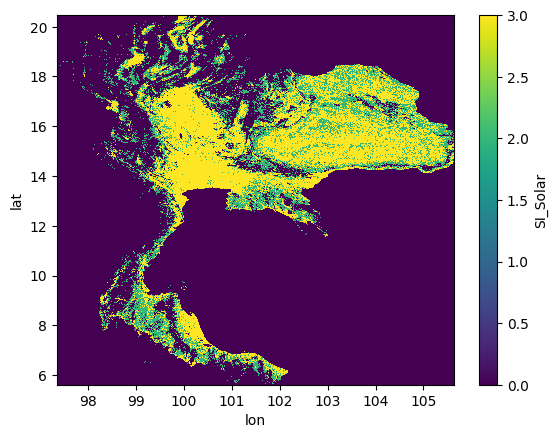

In [7]:
xr_slope_suitability_index['SI_Solar'].plot()

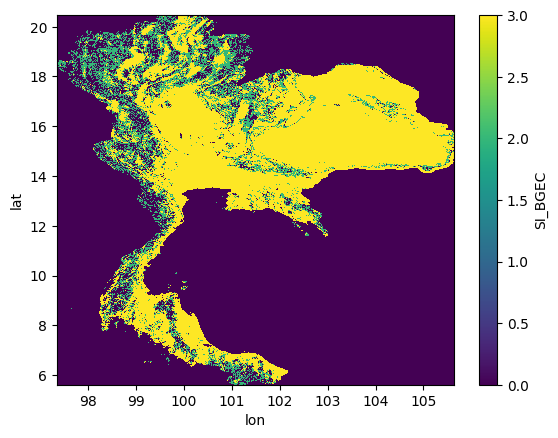

In [8]:
xr_slope_suitability_index['SI_BGEC'].plot()